### Librerias

In [151]:
pip install --upgrade numpy pandas scikit-learn

     ---------------------------------------- 8.9/8.9 MB 6.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Acceso denegado: 'C:\\Users\\hemer\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~klearn\\.libs\\msvcp140.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: c:\Users\hemer\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Carga datos

In [2]:
pip install openpyxl # Libreria necesaria para leer excel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [3]:
df = pd.read_csv("apartments_for_rent_classified_100K.csv", sep = ";", encoding = "latin1")

C:\Users\hemer\AppData\Local\Temp\ipykernel_9200\2748539418.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("apartments_for_rent_classified_100K.csv", sep = ";", encoding = "latin1")


In [4]:
pd.set_option('display.max_columns', None) # Codigo para poder ver todas las columnas con el head()

In [5]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

Del codigo anterior se perceibe que la variable **address** tiene sólo 8mil datos de 100K por lo que se eliminarás más adelante por conceptos de completitud

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,99492.0,5.358321e+09,1.847404e+08,5.121046e+09,5.197950e+09,5.508673e+09,5.509007e+09,5.669439e+09
bathrooms,99429.0,1.445323e+00,5.470206e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,9.000000e+00
bedrooms,99368.0,1.728212e+00,7.492005e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,9.000000e+00
price,99491.0,1.527057e+03,9.042459e+02,1.000000e+02,1.013000e+03,1.350000e+03,1.795000e+03,5.250000e+04
square_feet,99492.0,9.564307e+02,4.175715e+02,1.010000e+02,7.290000e+02,9.000000e+02,1.115000e+03,5.000000e+04
latitude,99467.0,3.694799e+01,4.599461e+00,1.957380e+01,3.374650e+01,3.722820e+01,3.995300e+01,6.483320e+01
longitude,99467.0,-9.156866e+01,1.581717e+01,-1.593698e+02,-1.047919e+02,-8.456230e+01,-7.760820e+01,-6.877880e+01
time,99492.0,1.559665e+09,1.105077e+07,1.544174e+09,1.550832e+09,1.568745e+09,1.568767e+09,1.577391e+09


In [8]:
df.nunique()

id               99408
category             7
title            58503
body             94503
amenities         9827
bathrooms           16
bedrooms            10
currency             1
fee                  2
has_photo            3
pets_allowed         4
price             3687
price_display     3718
price_type           3
square_feet       2538
address           7771
cityname          2979
state               51
latitude          7212
longitude         7270
source              25
time             75360
dtype: int64

Eliminacion de columnas:
- Del codigo anterior se extrae que las columnas **id, body, title, amenities, cityname** son variables que presentan un numero de categorìas elevados para utilizarse como insighr pot lo que no se utilizarán para el modelado
- Adicionalmente la columna **addres** se eliminarà por completitud al sòlo presentar 8mil datos por casi 100K del dataset
- La variable **Currency** sólo tiene un valor por lo que se eliminará
- Por ultimo la variable **Time** no es una variable que se pueda utilizar al ser una fecha

In [9]:
df_backup = df.copy()
df.drop(columns = ["id", "body", "title"
                   ,"amenities", "cityname"
                   ,"address"
                   ,"currency"
                   ,"time"
                   ],inplace = True)

In [11]:
df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,state,latitude,longitude,source
0,housing/rent/apartment,1.0,1.0,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,CA,33.8520,-118.3759,RentLingo
1,housing/rent/apartment,1.5,3.0,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,VA,37.0867,-76.4941,RentLingo
2,housing/rent/apartment,2.0,3.0,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,NC,35.8230,-78.6438,RentLingo
3,housing/rent/apartment,1.0,2.0,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820,CA,38.3622,-121.9712,RentLingo
4,housing/rent/apartment,1.0,1.0,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624,NM,35.1038,-106.6110,RentLingo


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       99492 non-null  object 
 1   bathrooms      99429 non-null  float64
 2   bedrooms       99368 non-null  float64
 3   fee            99492 non-null  object 
 4   has_photo      99492 non-null  object 
 5   pets_allowed   39068 non-null  object 
 6   price          99491 non-null  float64
 7   price_display  99491 non-null  object 
 8   price_type     99492 non-null  object 
 9   square_feet    99492 non-null  int64  
 10  state          99190 non-null  object 
 11  latitude       99467 non-null  float64
 12  longitude      99467 non-null  float64
 13  source         99492 non-null  object 
dtypes: float64(5), int64(1), object(8)
memory usage: 10.6+ MB


La variable **Price display** está siendo reconocida como object y no numerica, además en los ejemplos desplegados por pantalla en el head() paraciera ser igual al a variable **price** por lo que se hará in tratamiento de datos para evaluarla

In [13]:
df["price_display"] = df["price_display"].str.split().str[0].str.replace("$", "", regex = False).str.replace(",","", regex = False).astype("float")

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,99429.0,1.445323,0.547021,1.0000,1.0000,1.0000,2.0000,9.0000
bedrooms,99368.0,1.728212,0.749200,0.0000,1.0000,2.0000,2.0000,9.0000
price,99491.0,1527.057281,904.245882,100.0000,1013.0000,1350.0000,1795.0000,52500.0000
price_display,99491.0,1527.057281,904.245882,100.0000,1013.0000,1350.0000,1795.0000,52500.0000
square_feet,99492.0,956.430688,417.571522,101.0000,729.0000,900.0000,1115.0000,50000.0000
latitude,99467.0,36.947988,4.599461,19.5738,33.7465,37.2282,39.9530,64.8332
longitude,99467.0,-91.568656,15.817168,-159.3698,-104.7919,-84.5623,-77.6082,-68.7788


Dado que **price** y **price display** presentan los mismos valores también se eliminará esa variable

In [15]:
df.drop(columns =  ["price_display"], inplace = True)

In [16]:
df.nunique()

category           7
bathrooms         16
bedrooms          10
fee                2
has_photo          3
pets_allowed       4
price           3687
price_type         3
square_feet     2538
state             51
latitude        7212
longitude       7270
source            25
dtype: int64

In [109]:
df.isnull().sum()

category        0
bathrooms       0
bedrooms        0
fee             0
has_photo       0
pets_allowed    0
price           0
price_type      0
square_feet     0
state           0
latitude        0
longitude       0
source          0
dtype: int64

Se tomará como supuesto que la valta de valor de la variable **Pets_allowed** es una respuesta negativa ante la autorizacion de tener o no una mascota

In [17]:
df["pets_allowed"] = df["pets_allowed"].fillna("No")

In [18]:
df.dropna(inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99007 entries, 0 to 99491
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   category      99007 non-null  object 
 1   bathrooms     99007 non-null  float64
 2   bedrooms      99007 non-null  float64
 3   fee           99007 non-null  object 
 4   has_photo     99007 non-null  object 
 5   pets_allowed  99007 non-null  object 
 6   price         99007 non-null  float64
 7   price_type    99007 non-null  object 
 8   square_feet   99007 non-null  int64  
 9   state         99007 non-null  object 
 10  latitude      99007 non-null  float64
 11  longitude     99007 non-null  float64
 12  source        99007 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 10.6+ MB


En base a que las variables ya se encuentran correctamente seleccionadas y con un numero de categorìas que hacen sentido, se procederá a eliminar todos los registros que presenten algún nulo

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99007 entries, 0 to 99491
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   category      99007 non-null  object 
 1   bathrooms     99007 non-null  float64
 2   bedrooms      99007 non-null  float64
 3   fee           99007 non-null  object 
 4   has_photo     99007 non-null  object 
 5   pets_allowed  99007 non-null  object 
 6   price         99007 non-null  float64
 7   price_type    99007 non-null  object 
 8   square_feet   99007 non-null  int64  
 9   state         99007 non-null  object 
 10  latitude      99007 non-null  float64
 11  longitude     99007 non-null  float64
 12  source        99007 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 10.6+ MB


Sólo se perdieron 1000 registros del total del dataset por lo que es bastante aceptable de cara a trabajar con el numero de datos obtenido

### EDA

In [114]:
df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,price_type,square_feet,state,latitude,longitude,source
0,housing/rent/apartment,1.0,1.0,No,Thumbnail,Cats,2195.0,Monthly,542,CA,33.8520,-118.3759,RentLingo
1,housing/rent/apartment,1.5,3.0,No,Thumbnail,"Cats,Dogs",1250.0,Monthly,1500,VA,37.0867,-76.4941,RentLingo
2,housing/rent/apartment,2.0,3.0,No,Thumbnail,No,1395.0,Monthly,1650,NC,35.8230,-78.6438,RentLingo
3,housing/rent/apartment,1.0,2.0,No,Thumbnail,"Cats,Dogs",1600.0,Monthly,820,CA,38.3622,-121.9712,RentLingo
4,housing/rent/apartment,1.0,1.0,No,Thumbnail,"Cats,Dogs",975.0,Monthly,624,NM,35.1038,-106.6110,RentLingo


<Axes: >

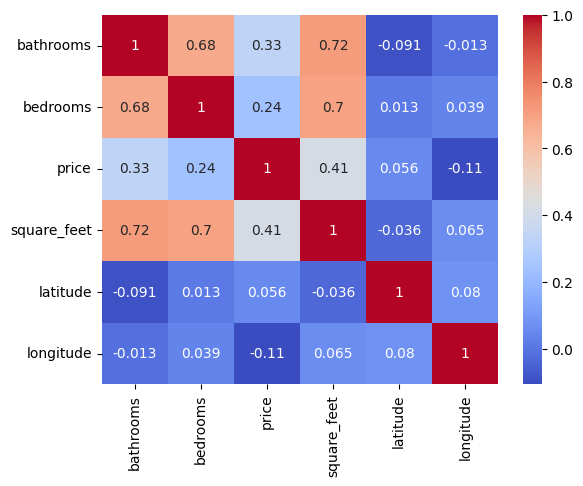

In [21]:
sns.heatmap(df.select_dtypes(["int", "float"]).corr()
            ,annot = True
            ,cmap = "coolwarm"
            )

# Feature Engineering

In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,99007.0,1.445893,0.547158,1.0000,1.0000,1.0000,2.0000,9.0000
bedrooms,99007.0,1.728696,0.748697,0.0000,1.0000,2.0000,2.0000,9.0000
price,99007.0,1525.646197,898.955283,100.0000,1013.5000,1350.0000,1795.0000,52500.0000
square_feet,99007.0,956.072651,365.387944,107.0000,730.0000,900.0000,1115.0000,12000.0000
latitude,99007.0,36.941613,4.603572,19.5738,33.7435,37.2139,39.9559,64.8332
longitude,99007.0,-91.544174,15.825494,-159.3698,-104.8171,-84.5465,-77.5767,-68.7788


In [ ]:
sns.

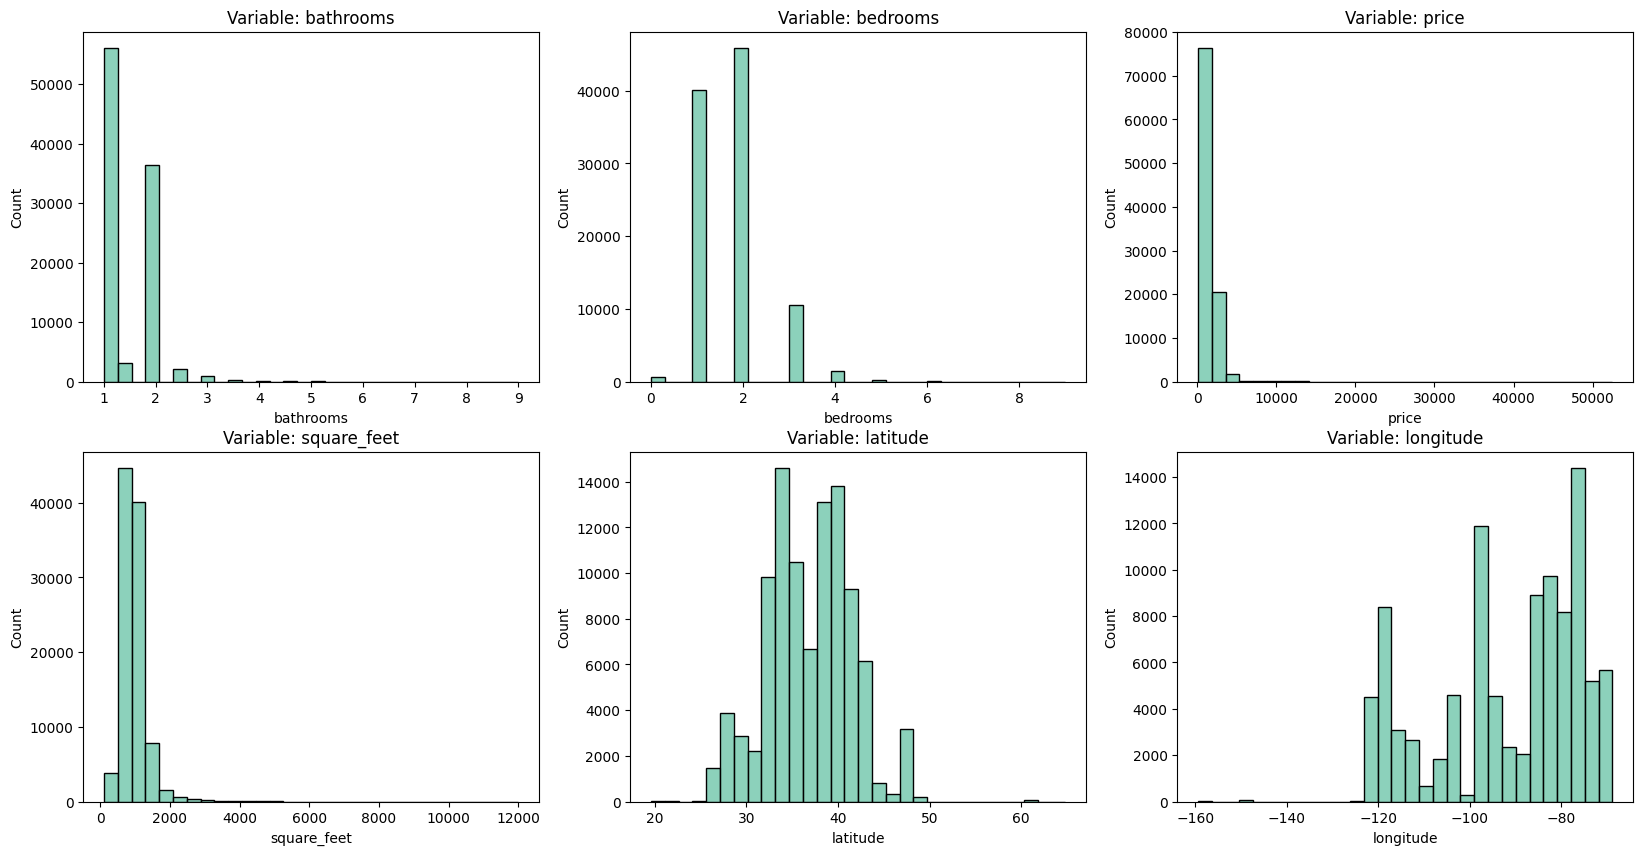

In [147]:
fig, axes = plt.subplots(2,3, figsize = (20,10))

axes= axes.flatten()

for i , col in enumerate(df.select_dtypes(["int", "float"]).columns):
    sns.histplot(df, x = col, ax= axes[i], bins = 30)
    axes[i].set_title(f"Variable: {col}")

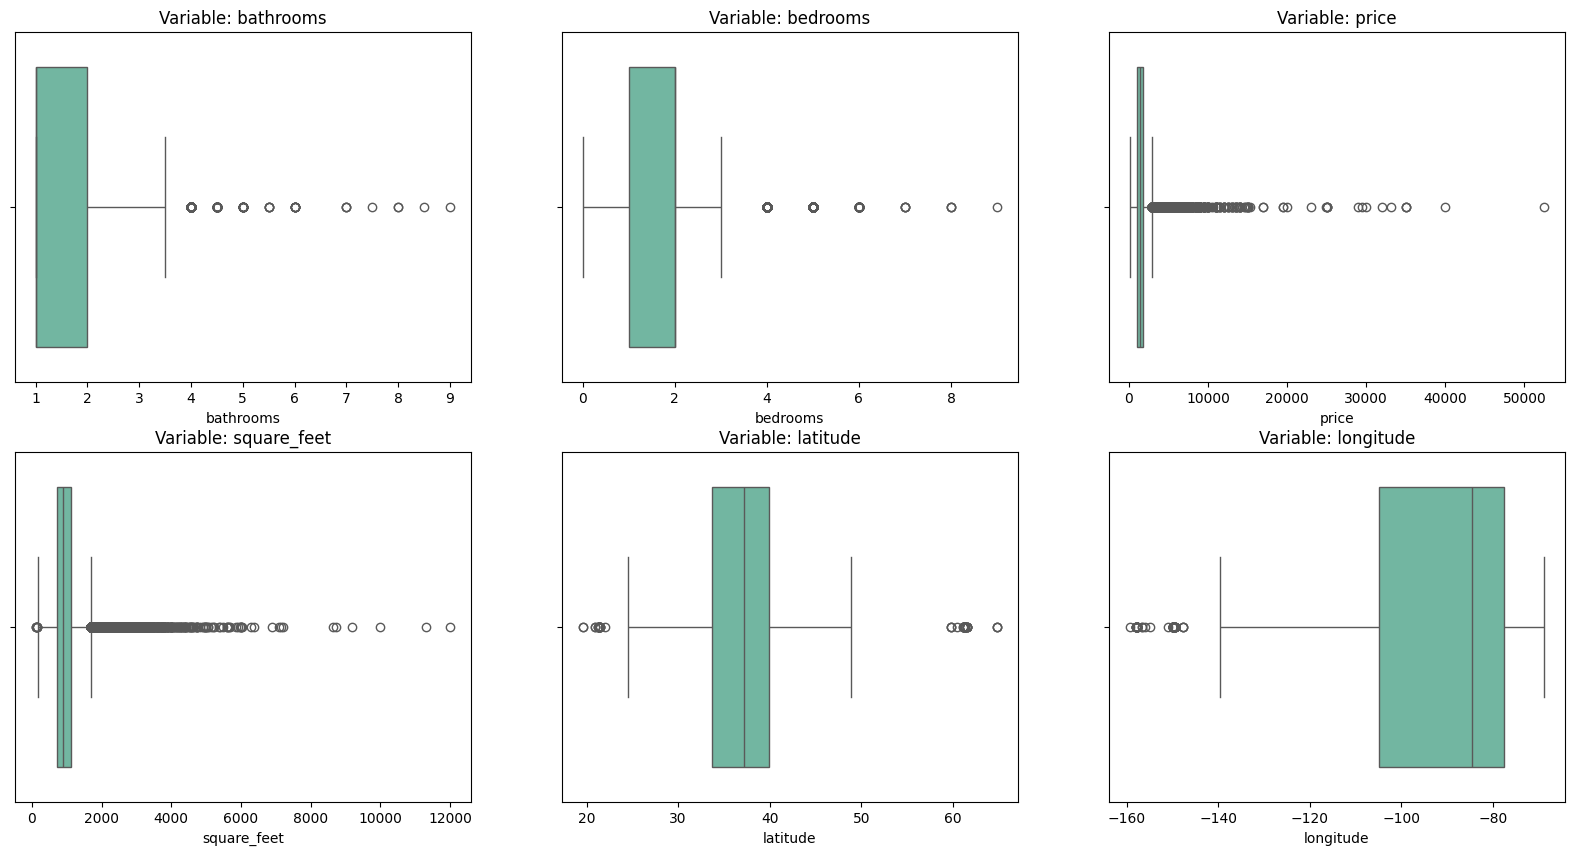

In [148]:
fig, axes = plt.subplots(2,3, figsize = (20,10))

axes= axes.flatten()

for i , col in enumerate(df.select_dtypes(["int", "float"]).columns):
    sns.boxplot(df, x = col, ax= axes[i])
    axes[i].set_title(f"Variable: {col}")

In [28]:
df_mod = df.copy()

In [29]:
var_num = df.select_dtypes(["int", "float"]).columns
scaler = StandardScaler()
df_mod[var_num] = scaler.fit_transform(df[var_num])

### Modelado

### Eleccion y explicacion de clusters